# EJERCICIO S1: ESTIMACIÓN VS REGRESIÓN (ML)

Principales pasos: 

1.	A través de la simulación secuencial gaussiana se creará un escenario exhaustivo para una variable llamada “VA”. 
2.	Se extrae una muestra dispersa de VA, equivalente al 4% del total de datos.
3.	Se utiliza el modelo variograma real para estimar con Kriging Ordinario en una malla igual a las dimensiones de la simulación. 
4.	Se entrena un modelo de regresión (ML) y se utiliza para predecir VA en lugares no muestreados. 
5.	Se compararán los resultados a nivel visual y a través de la correlación lineal de Pearson. 

In [7]:
import geostatspy.GSLIB as GSLIB                          # Utilidades GSLIB y funciones envueltas
import geostatspy.geostats as geostats                    # GSLIB convertido a Python
import os                                                 # Para configurar el directorio de trabajo
import numpy as np                                        # Biblioteca de funciones matemáticas
import pandas as pd                                       # Biblioteca para manipulación de marcos de datos
import matplotlib.pyplot as plt                           # Biblioteca para salida gráfica
import scipy.stats                                        # Biblioteca de resumenes estadísticos y matemáticos
import random as rand
os.chdir("C:/Users/nubem/Documents/NUBEMINERA_2020/GSLIB_FOLDER") # ruta de ejecutables de GSLIB

**1. Creación del escenario simulado 2D**

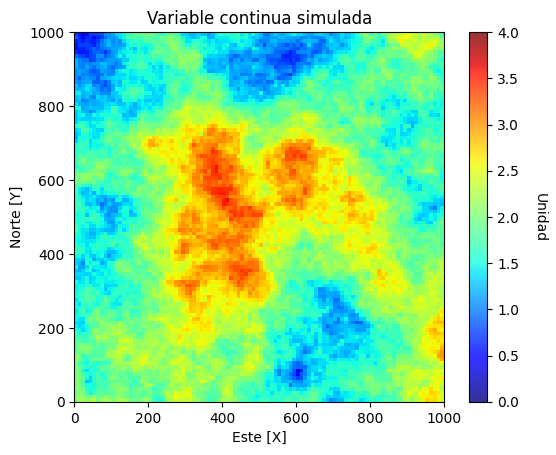

In [8]:
# Modeling parameters, the model grid, the random seed, the target distribution, and color bar
nx = 100; ny = 100; cell_size=10                             # grid number of cells and cell size

xmin = 0; ymin =0;                                          # grid origin

xmax = 1000; ymax = 1000    # calculate the extent of model
seed = 172763650

vmin = 0; vmax = 1; cmap = plt.cm.jet                     # color min and max and using the plasma color map

# Make a truth model / unconditional simulation
va_mean = 2; va_stdev = 0.55; va_cmin = 0; va_cmax = 4

var = GSLIB.make_variogram(nug=0.0,nst=1,it1=1,cc1=1.0,azi1=90,hmaj1=500,hmin1=500)

VA = GSLIB.sgsim_uncond(1,nx,ny,cell_size,seed,var,"u")

VA = GSLIB.affine(VA,va_mean,va_stdev)

GSLIB.pixelplt_st(VA,xmin,xmax,ymin,ymax,cell_size,va_cmin,va_cmax,"Variable continua simulada","Este [X]","Norte [Y]","Unidad",cmap)
plt.show()

In [9]:
df_zko = pd.DataFrame(VA)
df11 = df_zko.stack().reset_index().rename(columns={"level_0": "Norte[Y]", "level_1": "Este[X]", 0:"VA"})

x = df11["Norte[Y]"].iloc[::-1].reset_index()

df11["Norte[Y]"] = x["Norte[Y]"]

##############################################################################################################

grid_x = np.linspace(0,1000, num=100, endpoint=False) #Coord. de origen x, coord. de termino x, nª de celdas x.
grid_y = np.linspace(0,1000, num=100, endpoint=False) #Coord. de origen y, coord. de termino y, nª de celdas y.

#En este caso la matriz es de 100 x 100 celdas.

gy = np.array(grid_y) #conversión a un array de numpy 
gx = np.array(grid_x) #conversión a un array de numpy 

yg, xg = np.meshgrid(grid_x, grid_y, indexing='ij') #Creación de la grilla (intersecciones en yg; xg)

x_g = xg.ravel() #aplanamiento de xg
y_g = yg.ravel() #aplanamiento de yg

d = {'Este[X]': x_g, 'Norte[Y]': y_g} #Columnas con coordenadas X e Y.
df = pd.DataFrame(data=d) #Creación del dataframe 

h = df["Norte[Y]"].iloc[::-1].reset_index()

df["Norte[Y]"] = h["Norte[Y]"]

df["VA"] = df11["VA"] #Traspaso de la columna VA al nuevo DataFrame.
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Este[X],10000.0,495.0,288.675135,0.000000,247.500000,495.000000,742.500000,990.000000
Norte[Y],10000.0,495.0,288.675135,0.000000,247.500000,495.000000,742.500000,990.000000
VA,10000.0,2.0,0.550028,0.442244,1.604565,1.950329,2.378273,3.617781


**2. Extracción muestra:**

In [11]:
# Make a datset by sampling from the truth model, and display the histogram and location map
mx = 20; my =20

sample_data1 = GSLIB.regular_sample(VA,xmin,xmax,ymin,ymax,cell_size,mx,my,nx,ny,"VA")

nsamp_random = 384

sample_data2 = GSLIB.random_sample(VA,xmin,xmax,ymin,ymax,cell_size,nsamp_random,'VA')

sample_data = pd.concat([sample_data1,sample_data2],ignore_index = True)

print((sample_data["VA"].count() * 100/df11["VA"].count()), "% es el tamaño de la muestra")

4.0 % es el tamaño de la muestra


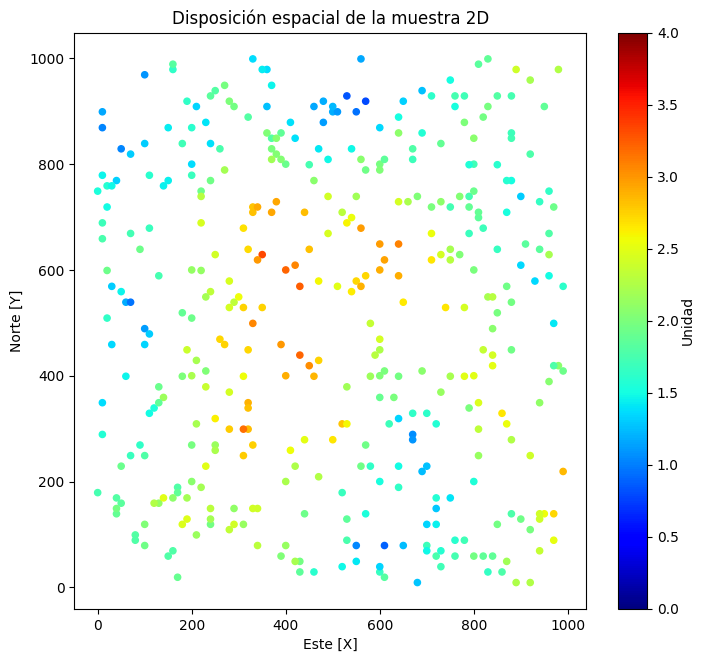

In [15]:
marker_size=20
plt.subplot(111)
plt.scatter(sample_data["X"], sample_data["Y"], marker_size, sample_data["VA"], cmap = plt.cm.jet)
plt.xlabel('Este [X]')
plt.ylabel('Norte [Y]')
plt.title('Disposición espacial de la muestra 2D')
plt.grid(False)
cbar=plt.colorbar()
plt.clim(0,4)

cbar.set_label('Unidad', labelpad=+1)
plt.subplots_adjust(left=0, bottom=0.0, right=1, top=1.2, wspace=0.2, hspace=0.2)
plt.show()

In [16]:
sample_data.describe().T

,count,mean,std,min,25%,50%,75%,max
X,400.0,496.975000,285.155015,0.000000,240.00000,510.000000,750.000000,990.00000
Y,400.0,505.715000,291.503232,9.000000,249.00000,529.000000,761.500000,999.00000
VA,400.0,1.981972,0.506328,0.782428,1.62492,1.945928,2.326276,3.33856


**3. Estimación Kriging Ordinario:**

In [17]:
vario_kri = GSLIB.make_variogram(nug=0.0,nst=1,it1=1,cc1=1.0,azi1=90,hmaj1=500,hmin1=500) #ajuste con un unico modelo esférico 

In [18]:
nx = 100; ny=100; xsiz=10; ysiz=10; xmn=0; ymn= 0; ndmax=20; ndmin=1;radius=500; 

ktype=1; skmean=0; nxdis=1; nydis=1; tmin=-9999; tmax=9999

kmap, vmap = geostats.kb2d(sample_data, "X", "Y", "VA", tmin, tmax, nx, xmn, xsiz, ny, ymn, ysiz, nxdis, nydis, ndmin, ndmax, radius, ktype, skmean, vario_kri)

  Estimated   10000 blocks 
      average   1.9965496257503996  variance  0.2509349948449411


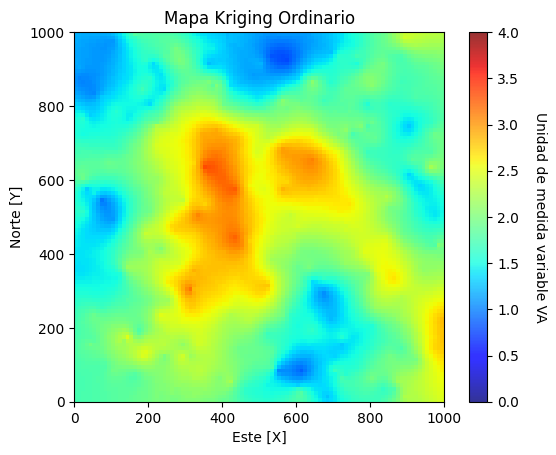

In [19]:
GSLIB.pixelplt_st(kmap,xmin,xmax,ymin,ymax,1,0,4,"Mapa Kriging Ordinario", "Este [X]", "Norte [Y]", "Unidad de medida variable VA", cmap)

In [20]:
df_kmap = pd.DataFrame(kmap) #se pasan los valores estimados al dataframe de la simulación 
df_kmap = df_kmap.stack().reset_index().rename(columns={"level_0": "Norte[Y]", "level_1": "Este[X]", 0:"VA"})

df["VA_KO"]= df_kmap["VA"]
df.head()

,Este[X],Norte[Y],VA,VA_KO
0,0.0,990.0,0.754091,1.200693
1,10.0,990.0,0.598761,1.193488
2,20.0,990.0,0.442244,1.187350
3,30.0,990.0,0.554724,1.177956
4,40.0,990.0,0.758951,1.173564


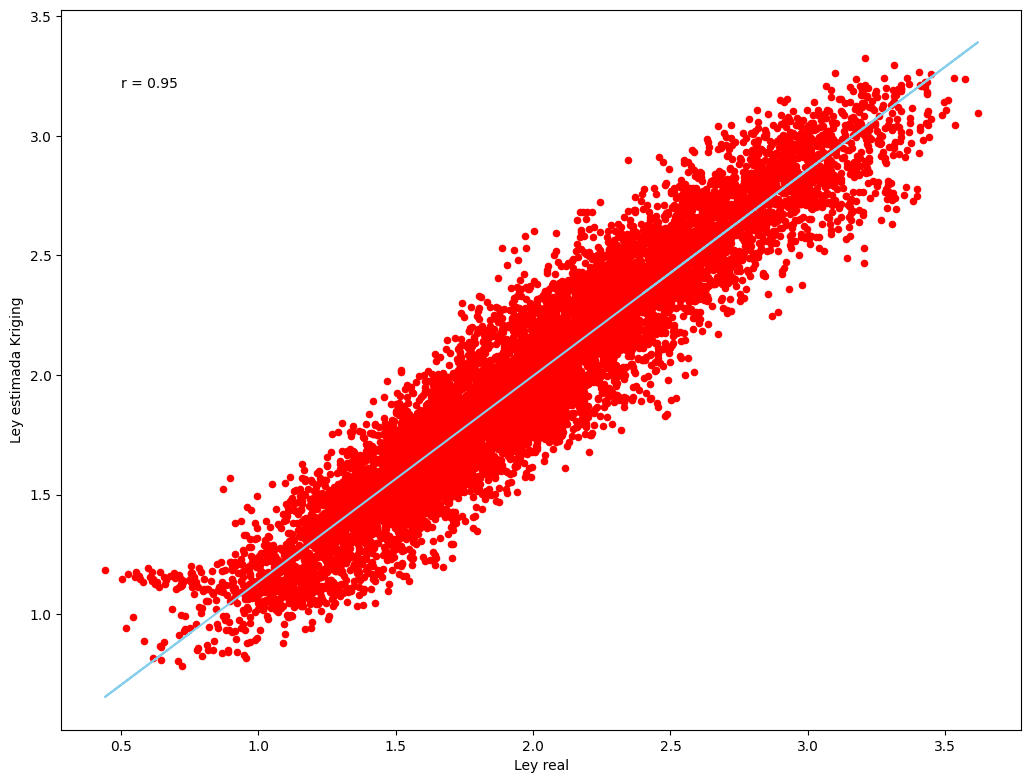

In [21]:
x = df["VA"] 
y = df["VA_KO"] 
#Calculando los coeficientes del ajuste de regresión:
a, b = np.polyfit(x, y, 1) # 1 es el grado del polinomio
r = np.corrcoef(x, y) # r = coeficiente de correlación
#print("R:", r, "a:", a, "b:", b) # b: pendiente de la recta, a: ordenada en la vertical (Y = bX + a)
plt.subplot(111)
plt.scatter(x,y, color="r", s=20)
plt.xlabel("Ley real")
plt.ylabel("Ley estimada Kriging")
plt.plot(x, a * x + b, color="skyblue")
plt.text(0.5,3.2, 'r = {0:2.2f}'.format(r[0,1]))
plt.subplots_adjust(left=0.0, bottom=0.0, right=1.5, top=1.5)
plt.show()

**4. Implementación Regresor ML:**

In [22]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import models
from tensorflow.keras import layers
from keras.optimizers import RMSprop 
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [23]:
X = sample_data.drop('VA',axis=1) 
X.head()

,X,Y
0,200.0,800.0
1,200.0,600.0
2,200.0,400.0
3,200.0,200.0
4,400.0,800.0


In [24]:
y = sample_data["VA"]
y

0      1.364708
1      2.115032
2      2.226239
3      2.070056
4      1.916981
         ...   
395    2.415854
396    1.403564
397    1.225089
398    3.245625
399    1.481369
Name: VA, Length: 400, dtype: float64

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=17276)

In [26]:
X_train.shape

(320, 2)

In [27]:
X_test.shape

(80, 2)

In [28]:
X_train = pd.DataFrame(StandardScaler().fit_transform(X_train))
X_test = pd.DataFrame(StandardScaler().fit_transform(X_test))
X_train.rename(columns={0:"x", 1:"y"}, inplace=True)
X_test.rename(columns={0:"x", 1:"y"}, inplace=True)

In [29]:
# Definición de la arquitectura de la red neuronal

network = models.Sequential()

network.add(layers.Dense(36, activation='relu', input_shape=X_train.shape[1:]))
network.add(layers.Dense(18, activation='relu'))
network.add(layers.Dense(1)) #la última capa no tiene función de activación cuando se trata de regresión

network.summary()

C:\Users\nubem\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 36)                  │             108 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 18)                  │             666 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              19 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 793 (3.10 KB)

 Trainable params: 793 (3.10 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
network.compile(
   loss = 'mean_squared_error', 
   optimizer = RMSprop()
)

In [31]:
history = network.fit(X_train, 
                      y_train, 
                      epochs=500, 
                      batch_size = 128,
                      validation_data=(X_test, y_test))

Epoch 1/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 158ms/step - loss: 3.8346 - val_loss: 2.9467
Epoch 2/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 3.2163 - val_loss: 2.6158
Epoch 3/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 2.9671 - val_loss: 2.3539
Epoch 4/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 2.6188 - val_loss: 2.1257
Epoch 5/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 2.4623 - val_loss: 1.9208
Epoch 6/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 2.1731 - val_loss: 1.7384
Epoch 7/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 2.0520 - val_loss: 1.5822
Epoch 8/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 1.8913 - val_loss: 1.4481
Epoch 9/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 1.7416 - val_loss: 1.3343
Epoch 10/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 1.5799 - val_loss: 1.2309
Epoch 11/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 1.5120 - val_loss: 1.1364
Epoch 12/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 1.3611 - val_l

Epoch 84/500
3/3 [==============================] - 0s 57ms/step - loss: 0.1088 - val_loss: 0.1173
Epoch 85/500
3/3 [==============================] - 0s 40ms/step - loss: 0.1073 - val_loss: 0.1040
Epoch 86/500
3/3 [==============================] - 0s 41ms/step - loss: 0.1049 - val_loss: 0.1015
Epoch 87/500
3/3 [==============================] - 0s 53ms/step - loss: 0.1020 - val_loss: 0.1026
Epoch 88/500
3/3 [==============================] - 0s 44ms/step - loss: 0.1030 - val_loss: 0.0988
Epoch 89/500
3/3 [==============================] - 0s 53ms/step - loss: 0.0999 - val_loss: 0.0960
Epoch 90/500
3/3 [==============================] - 0s 52ms/step - loss: 0.0997 - val_loss: 0.0945
Epoch 91/500
3/3 [==============================] - 0s 60ms/step - loss: 0.0970 - val_loss: 0.0950
Epoch 92/500
3/3 [==============================] - 0s 49ms/step - loss: 0.0935 - val_loss: 0.0945
Epoch 93/500
3/3 [==============================] - 0s 47ms/step - loss: 0.0923 - val_loss: 0.1023
Epoch 94/5

3/3 [==============================] - 0s 37ms/step - loss: 0.0632 - val_loss: 0.0656
Epoch 167/500
3/3 [==============================] - 0s 54ms/step - loss: 0.0624 - val_loss: 0.0628
Epoch 168/500
3/3 [==============================] - 0s 51ms/step - loss: 0.0634 - val_loss: 0.0647
Epoch 169/500
3/3 [==============================] - 0s 48ms/step - loss: 0.0646 - val_loss: 0.0715
Epoch 170/500
3/3 [==============================] - 0s 42ms/step - loss: 0.0629 - val_loss: 0.0627
Epoch 171/500
3/3 [==============================] - 0s 43ms/step - loss: 0.0608 - val_loss: 0.0694
Epoch 172/500
3/3 [==============================] - 0s 51ms/step - loss: 0.0618 - val_loss: 0.0674
Epoch 173/500
3/3 [==============================] - 0s 46ms/step - loss: 0.0626 - val_loss: 0.0615
Epoch 174/500
3/3 [==============================] - 0s 44ms/step - loss: 0.0605 - val_loss: 0.0607
Epoch 175/500
3/3 [==============================] - 0s 40ms/step - loss: 0.0602 - val_loss: 0.0624
Epoch 176/500


3/3 [==============================] - 0s 43ms/step - loss: 0.0516 - val_loss: 0.0532
Epoch 249/500
3/3 [==============================] - 0s 34ms/step - loss: 0.0520 - val_loss: 0.0589
Epoch 250/500
3/3 [==============================] - 0s 38ms/step - loss: 0.0511 - val_loss: 0.0585
Epoch 251/500
3/3 [==============================] - 0s 51ms/step - loss: 0.0526 - val_loss: 0.0623
Epoch 252/500
3/3 [==============================] - 0s 40ms/step - loss: 0.0527 - val_loss: 0.0577
Epoch 253/500
3/3 [==============================] - 0s 38ms/step - loss: 0.0505 - val_loss: 0.0540
Epoch 254/500
3/3 [==============================] - 0s 64ms/step - loss: 0.0517 - val_loss: 0.0576
Epoch 255/500
3/3 [==============================] - 0s 56ms/step - loss: 0.0497 - val_loss: 0.0531
Epoch 256/500
3/3 [==============================] - 0s 43ms/step - loss: 0.0514 - val_loss: 0.0544
Epoch 257/500
3/3 [==============================] - 0s 40ms/step - loss: 0.0524 - val_loss: 0.0646
Epoch 258/500


Epoch 330/500
3/3 [==============================] - 0s 57ms/step - loss: 0.0469 - val_loss: 0.0506
Epoch 331/500
3/3 [==============================] - 0s 54ms/step - loss: 0.0449 - val_loss: 0.0509
Epoch 332/500
3/3 [==============================] - 0s 50ms/step - loss: 0.0458 - val_loss: 0.0520
Epoch 333/500
3/3 [==============================] - 0s 63ms/step - loss: 0.0456 - val_loss: 0.0538
Epoch 334/500
3/3 [==============================] - 0s 54ms/step - loss: 0.0482 - val_loss: 0.0488
Epoch 335/500
3/3 [==============================] - 0s 57ms/step - loss: 0.0448 - val_loss: 0.0539
Epoch 336/500
3/3 [==============================] - 0s 44ms/step - loss: 0.0456 - val_loss: 0.0501
Epoch 337/500
3/3 [==============================] - 0s 75ms/step - loss: 0.0463 - val_loss: 0.0536
Epoch 338/500
3/3 [==============================] - 0s 83ms/step - loss: 0.0502 - val_loss: 0.0524
Epoch 339/500
3/3 [==============================] - 0s 78ms/step - loss: 0.0470 - val_loss: 0.0499


Epoch 412/500
3/3 [==============================] - 0s 142ms/step - loss: 0.0414 - val_loss: 0.0484
Epoch 413/500
3/3 [==============================] - 0s 119ms/step - loss: 0.0433 - val_loss: 0.0453
Epoch 414/500
3/3 [==============================] - 0s 120ms/step - loss: 0.0429 - val_loss: 0.0479
Epoch 415/500
3/3 [==============================] - 0s 162ms/step - loss: 0.0444 - val_loss: 0.0476
Epoch 416/500
3/3 [==============================] - 0s 138ms/step - loss: 0.0416 - val_loss: 0.0450
Epoch 417/500
3/3 [==============================] - 0s 177ms/step - loss: 0.0414 - val_loss: 0.0497
Epoch 418/500
3/3 [==============================] - 0s 110ms/step - loss: 0.0421 - val_loss: 0.0497
Epoch 419/500
3/3 [==============================] - 0s 216ms/step - loss: 0.0435 - val_loss: 0.0538
Epoch 420/500
3/3 [==============================] - 0s 120ms/step - loss: 0.0462 - val_loss: 0.0448
Epoch 421/500
3/3 [==============================] - 0s 176ms/step - loss: 0.0412 - val_los

Epoch 494/500
3/3 [==============================] - 0s 60ms/step - loss: 0.0396 - val_loss: 0.0435
Epoch 495/500
3/3 [==============================] - 0s 91ms/step - loss: 0.0407 - val_loss: 0.0455
Epoch 496/500
3/3 [==============================] - 0s 91ms/step - loss: 0.0418 - val_loss: 0.0465
Epoch 497/500
3/3 [==============================] - 0s 76ms/step - loss: 0.0390 - val_loss: 0.0457
Epoch 498/500
3/3 [==============================] - 0s 58ms/step - loss: 0.0397 - val_loss: 0.0565
Epoch 499/500
3/3 [==============================] - 0s 87ms/step - loss: 0.0454 - val_loss: 0.0460
Epoch 500/500
3/3 [==============================] - 0s 92ms/step - loss: 0.0391 - val_loss: 0.0452


<Axes: >

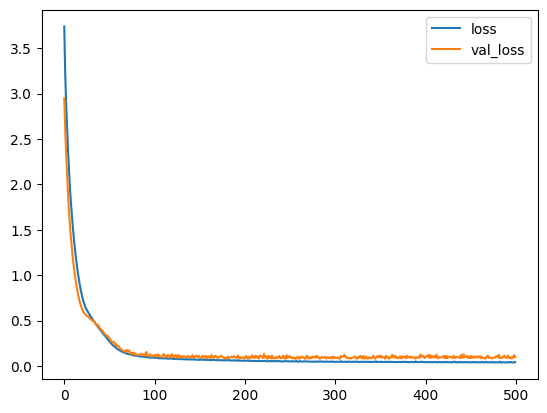

In [32]:
model_loss = pd.DataFrame(network.history.history)
model_loss.plot()

In [33]:
test_loss = network.evaluate(X_test, y_test)
print('test_mse:', test_loss)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1056
test_mse: 0.09924551099538803


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


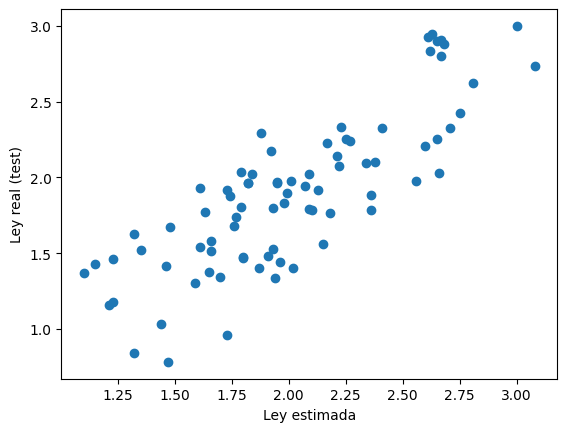

In [34]:
y_pred = network.predict(X_test).round(2)

plt.scatter(y_pred,y_test) #comparación valores reales del conjunto de prueba vs predicciones del modelo
plt.xlabel("Ley estimada")
plt.ylabel("Ley real (test)")
plt.show()

In [35]:
df.head()

,Este[X],Norte[Y],VA,VA_KO
0,0.0,990.0,0.754091,1.200693
1,10.0,990.0,0.598761,1.193488
2,20.0,990.0,0.442244,1.187350
3,30.0,990.0,0.554724,1.177956
4,40.0,990.0,0.758951,1.173564


In [36]:
df_malla = pd.DataFrame()

df_malla["X"] = df["Este[X]"]
df_malla["Y"] = df["Norte[Y]"]

df_malla = pd.DataFrame(StandardScaler().fit_transform(df_malla))
df_malla.rename(columns={0:"X", 1:"Y"}, inplace=True)

df_malla.head()

,X,Y
0,-1.714816,1.714816
1,-1.680173,1.714816
2,-1.645531,1.714816
3,-1.610888,1.714816
4,-1.576245,1.714816


In [37]:
y_pred = network.predict(df_malla).round(2) #uso del modelo para un conjunto nuevo de datos de entrada (bloques zona óxido)
df["VA_RNA"] = y_pred
df.head()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


,Este[X],Norte[Y],VA,VA_KO,VA_RNA
0,0.0,990.0,0.754091,1.200693,1.00
1,10.0,990.0,0.598761,1.193488,1.03
2,20.0,990.0,0.442244,1.187350,1.06
3,30.0,990.0,0.554724,1.177956,1.08
4,40.0,990.0,0.758951,1.173564,1.11


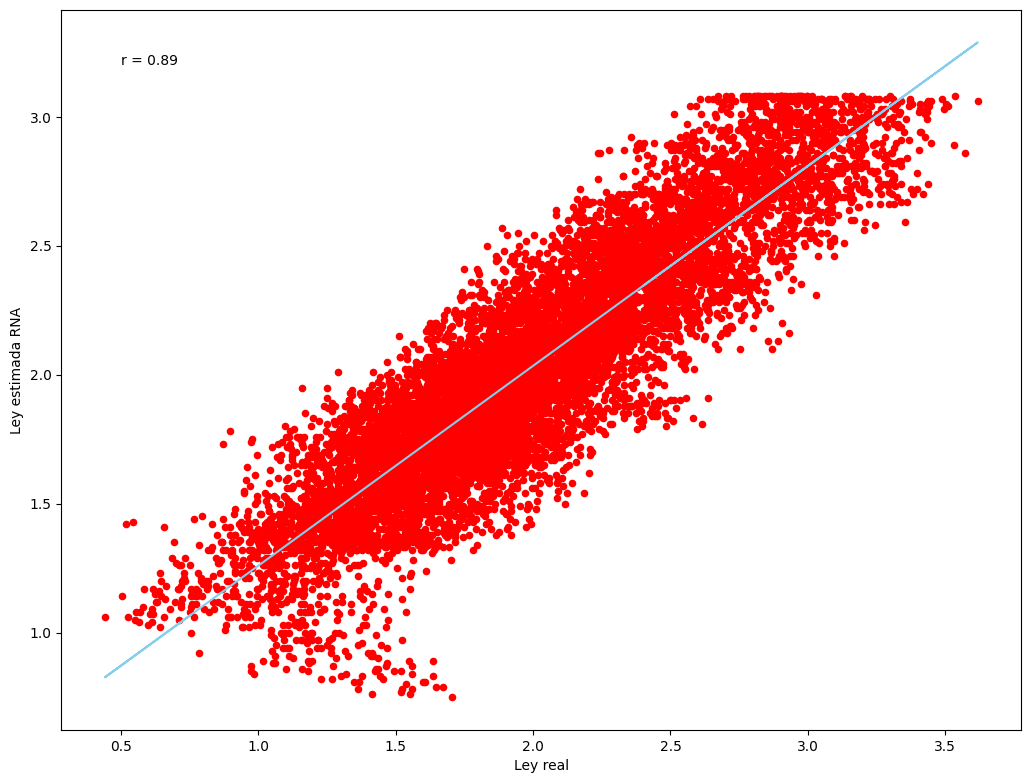

In [38]:
x = df["VA"] 
y = df["VA_RNA"] 
#Calculando los coeficientes del ajuste de regresión:
a, b = np.polyfit(x, y, 1) # 1 es el grado del polinomio
r = np.corrcoef(x, y) # r = coeficiente de correlación
#print("R:", r, "a:", a, "b:", b) # b: pendiente de la recta, a: ordenada en la vertical (Y = bX + a)
plt.subplot(111)
plt.scatter(x,y, color="r", s=20)
plt.xlabel("Ley real")
plt.ylabel("Ley estimada RNA")
plt.plot(x, a * x + b, color="skyblue")
plt.text(0.5,3.2, 'r = {0:2.2f}'.format(r[0,1]))
plt.subplots_adjust(left=0.0, bottom=0.0, right=1.5, top=1.5)
plt.show()

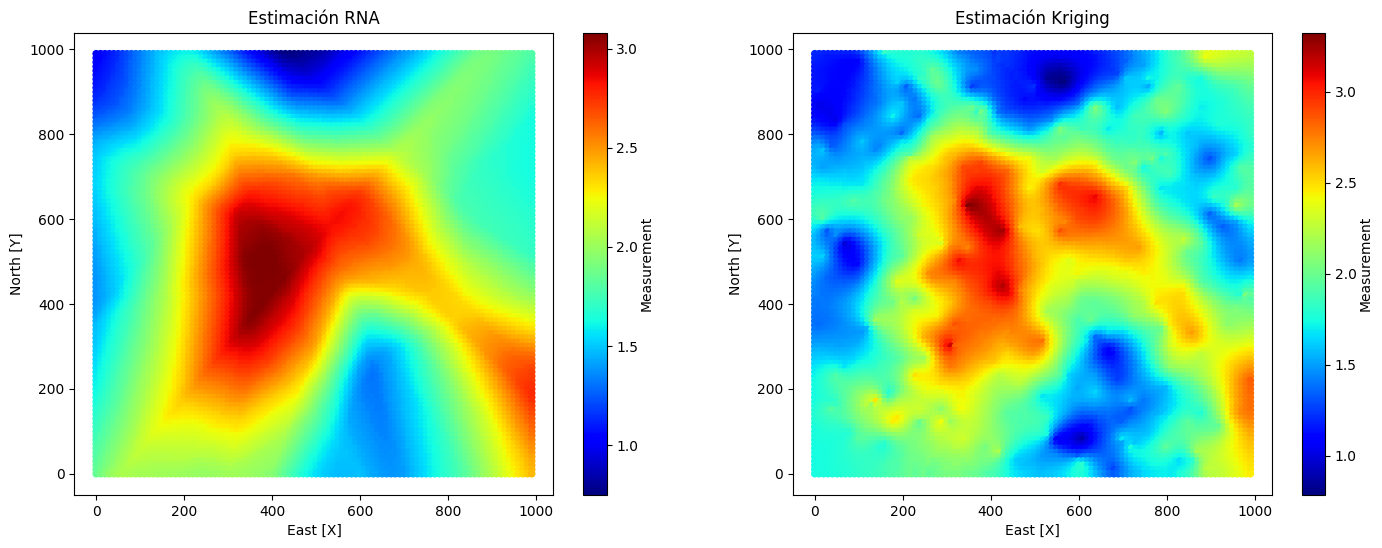

In [39]:
fig = plt.figure(figsize=(17,6))
plt.subplot(121)
plt.scatter(df["Este[X]"], df["Norte[Y]"], marker_size, df["VA_RNA"], cmap = plt.cm.jet)
plt.title("Estimación RNA")
plt.xlabel('East [X]')
plt.ylabel('North [Y]')
plt.grid(False)
cbar=plt.colorbar()
cbar.set_label('Measurement', labelpad=+1)
plt.subplot(122)
plt.scatter(df["Este[X]"], df["Norte[Y]"], marker_size, df["VA_KO"], cmap = plt.cm.jet)
plt.title("Estimación Kriging")
plt.xlabel('East [X]')
plt.ylabel('North [Y]')
plt.grid(False)
cbar=plt.colorbar()
cbar.set_label('Measurement', labelpad=+1)
plt.show()